# Порівняння моделей: CatBoost vs LightGBM vs XGBoost vs RandomForest vs Ridge

Мета цього ноутбука — перевірити, чи CatBoost і надалі лишається найкращим вибором для
`main.ipynb` після додавання нових ознак (`is_luxury_brand`, `Gearbox_simple`, `Engine_missing`,
`log_Mileage`, `Age_x_Mileage`, `Decade`), чи варто перейти на іншу модель.

**Підхід:**
- однакове очищення даних та однаковий набір ознак для всіх моделей;
- **гібридне кодування категорій**: CatBoost / LightGBM / XGBoost отримують нативні категоріальні
  колонки (`Mark`, `Model`, `Gearbox`, `Fuel_Type`, `Gearbox_simple`); RandomForest і Ridge не вміють
  працювати з рядковими категоріями напряму, тож для них високо-кардинальні `Mark`/`Model` кодуються
  частотним + target-кодуванням (рахується **лише на train-частині кожного фолду**, без витоку даних),
  а низько-кардинальні (`Gearbox`, `Fuel_Type`, `Gearbox_simple`) — one-hot;
- 5-Fold Cross-Validation з тими самими anti-leakage правилами, що й у `main.ipynb`
  (рідкісні марки/моделі та межі IQR рахуються окремо на train-частині кожного фолду).

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from catboost import CatBoostRegressor
import lightgbm as lgb
import xgboost as xgb

RANDOM_SEED = 42
CURRENT_YEAR = 2026
N_FOLDS = 5
MIN_COUNT = 10

LUXURY_MARKS = {
    'Aston Martin', 'BMW-Alpina', 'Lamborghini', 'Rolls-Royce', 'Ferrari',
    'Bentley', 'Porsche', 'Maserati', 'Lexus', 'Land Rover', 'Jaguar',
    'Mercedes-Benz', 'BMW', 'Audi', 'Lucid', 'Genesis',
}
AUTOMATIC_LIKE = {'Автомат', 'Типтронік', 'Варіатор', 'Робот'}

## Очищення даних та фічі (ідентично до `main.ipynb`)

In [2]:
data = pd.read_csv("../data/cars_dataset.csv")
df = data.copy()

df = df.drop(columns=['ID', 'Engine'], errors='ignore')
df = df[df['Price_USD'] > 0].copy()
df = df[df['Mark'] != 'Причеп'].copy()

df['Age'] = CURRENT_YEAR - df['Year']
df = df[(df['Age'] >= 0) & (df['Age'] <= 46)].copy()

split_data = df['Fuel'].str.split(', ', expand=True)
raw_fuel_type = split_data[0]
engine_from_split = pd.to_numeric(split_data[1].str.replace(' л.', '', regex=False), errors='coerce')
looks_like_engine = raw_fuel_type.str.match(r'^\d+(\.\d+)?\s*л\.?$', na=False)
df['Fuel_Type'] = np.where(looks_like_engine, 'Не вказано', raw_fuel_type)
engine_from_type = pd.to_numeric(raw_fuel_type.str.replace(' л.', '', regex=False), errors='coerce')
df['Engine_Capacity'] = np.where(looks_like_engine, engine_from_type, engine_from_split)
df['Engine_Capacity'] = df['Engine_Capacity'].fillna(0)
df = df.drop(columns=['Fuel'], errors='ignore')

df['Km_per_Year'] = df['Mileage'] / (df['Age'] + 1)
df['is_EV'] = (df['Fuel_Type'] == 'Електро').astype(int)
df['is_suspicious_mileage'] = ((df['Age'] > 10) & (df['Mileage'] < 50)).astype(int)
df['is_new'] = (df['Age'] <= 3).astype(int)

df['Mark'] = df['Mark'].fillna('Other')
df['Model'] = df['Model'].fillna('Other')
df['Gearbox'] = df['Gearbox'].fillna('Unknown')

df = df[(df['Price_USD'] >= 1000) & (df['Price_USD'] <= 250000) & (df['Engine_Capacity'] <= 10)].copy()

df['is_luxury_brand'] = df['Mark'].isin(LUXURY_MARKS).astype(int)
df['Gearbox_simple'] = np.where(df['Gearbox'].isin(AUTOMATIC_LIKE), 'Automatic_type', 'Manual_type')
df['Engine_missing'] = (df['Engine_Capacity'] == 0).astype(int)
df['log_Mileage'] = np.log1p(df['Mileage'])
df['Age_x_Mileage'] = df['Age'] * df['Mileage']
df['Decade'] = (df['Year'] // 10 * 10).astype(int)

print(f"Фінальний розмір датасету: {df.shape}")

num_features = [
    'Mileage', 'Age', 'Engine_Capacity', 'Km_per_Year',
    'is_EV', 'is_suspicious_mileage', 'is_new', 'is_luxury_brand',
    'Engine_missing', 'log_Mileage', 'Age_x_Mileage', 'Decade',
]
cat_features = ['Mark', 'Model', 'Gearbox', 'Fuel_Type', 'Gearbox_simple']
features = num_features + cat_features

X = df[features].copy()
y_log = np.log1p(df['Price_USD'])

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_SEED
)
X_train_full = X_train_full.copy()
X_test = X_test.copy()
print(f"Train: {len(X_train_full)}, Test: {len(X_test)}")

Фінальний розмір датасету: (18167, 19)
Train: 14533, Test: 3634


## Допоміжні функції CV

In [3]:
def group_rare(Xtr, Xval, cols, min_count=MIN_COUNT):
    Xtr = Xtr.copy(); Xval = Xval.copy()
    for col in cols:
        counts = Xtr[col].value_counts()
        valid = counts[counts >= min_count].index
        Xtr[col] = np.where(Xtr[col].isin(valid), Xtr[col], 'Other')
        Xval[col] = np.where(Xval[col].isin(valid), Xval[col], 'Other')
    return Xtr, Xval


def add_freq_target_enc(Xtr, ytr, Xval, cols, global_mean):
    """Частотне + target-кодування, зафіттоване ЛИШЕ на fold-train."""
    Xtr = Xtr.copy(); Xval = Xval.copy()
    for c in cols:
        freq = Xtr[c].value_counts(normalize=True)
        Xtr[f'{c}_freq'] = Xtr[c].map(freq).fillna(0)
        Xval[f'{c}_freq'] = Xval[c].map(freq).fillna(0)

        te = ytr.groupby(Xtr[c]).mean()
        Xtr[f'{c}_te'] = Xtr[c].map(te).fillna(global_mean)
        Xval[f'{c}_te'] = Xval[c].map(te).fillna(global_mean)
    return Xtr, Xval


HC_COLS = ['Mark', 'Model']
results_summary = {}


def run_cv(model_name, fit_predict_fn):
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    Xa = X_train_full.reset_index(drop=True)
    ya = y_train_full.reset_index(drop=True)
    fold_metrics = []
    t0 = time.time()
    for tr_idx, val_idx in kf.split(Xa):
        Xtr, Xval = Xa.iloc[tr_idx].copy(), Xa.iloc[val_idx].copy()
        ytr, yval = ya.iloc[tr_idx].copy(), ya.iloc[val_idx].copy()

        Xtr, Xval = group_rare(Xtr, Xval, ['Mark', 'Model'])

        Q1, Q3 = np.percentile(ytr, 25), np.percentile(ytr, 75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        mask = (ytr >= lo) & (ytr <= hi)
        Xtr, ytr = Xtr[mask], ytr[mask]

        pred = fit_predict_fn(Xtr, ytr, Xval)
        y_val_real = np.expm1(yval)
        y_pred = np.expm1(pred)
        mae = mean_absolute_error(y_val_real, y_pred)
        mape = mean_absolute_percentage_error(y_val_real, y_pred) * 100
        r2 = r2_score(y_val_real, y_pred)
        fold_metrics.append({'MAE': mae, 'MAPE': mape, 'R2': r2})
    dt = time.time() - t0
    fm = pd.DataFrame(fold_metrics)
    print(f"{model_name:14s} | MAE={fm['MAE'].mean():8,.0f} ±{fm['MAE'].std():6,.0f} | "
          f"MAPE={fm['MAPE'].mean():5.2f}% | R²={fm['R2'].mean():.4f} | час={dt:5.1f}с")
    results_summary[model_name] = {
        'MAE': fm['MAE'].mean(), 'MAE_std': fm['MAE'].std(),
        'MAPE': fm['MAPE'].mean(), 'R2': fm['R2'].mean(), 'time_s': dt,
    }
    return fm

## CatBoost (нативні категорії)

In [4]:
CAT_PARAMS = dict(
    iterations=1500, learning_rate=0.05, depth=8, l2_leaf_reg=5,
    loss_function='MAE', eval_metric='MAE', random_seed=RANDOM_SEED,
    verbose=0, one_hot_max_size=2000, early_stopping_rounds=120,
)

def cb_fp(Xtr, ytr, Xval):
    m = CatBoostRegressor(**CAT_PARAMS)
    m.fit(Xtr, ytr, cat_features=cat_features)
    return m.predict(Xval)

_ = run_cv('CatBoost', cb_fp)

CatBoost       | MAE=   3,367 ±   219 | MAPE=23.42% | R²=0.8255 | час= 43.9с


## LightGBM (нативні категорії через dtype `category`)

In [5]:
LGB_PARAMS = dict(
    n_estimators=1500, learning_rate=0.05, num_leaves=64, max_depth=8,
    reg_lambda=5, objective='mae', random_state=RANDOM_SEED, verbosity=-1,
)

def lgb_fp(Xtr, ytr, Xval):
    Xtr = Xtr.copy(); Xval = Xval.copy()
    for c in cat_features:
        Xtr[c] = Xtr[c].astype('category')
        Xval[c] = pd.Categorical(Xval[c], categories=Xtr[c].cat.categories)
    m = lgb.LGBMRegressor(**LGB_PARAMS)
    m.fit(Xtr, ytr, categorical_feature=cat_features)
    return m.predict(Xval)

_ = run_cv('LightGBM', lgb_fp)

/tmp/ipykernel_525/1785654600.py:10: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  Xval[c] = pd.Categorical(Xval[c], categories=Xtr[c].cat.categories)


LightGBM       | MAE=   3,396 ±   188 | MAPE=23.75% | R²=0.7990 | час= 19.4с


## XGBoost (нативні категорії, `enable_categorical`)

In [6]:
XGB_PARAMS = dict(
    n_estimators=1500, learning_rate=0.05, max_depth=8, reg_lambda=5,
    objective='reg:absoluteerror', random_state=RANDOM_SEED,
    enable_categorical=True, tree_method='hist', verbosity=0, n_jobs=4,
)

def xgb_fp(Xtr, ytr, Xval):
    Xtr = Xtr.copy(); Xval = Xval.copy()
    for c in cat_features:
        Xtr[c] = Xtr[c].astype('category')
        Xval[c] = pd.Categorical(Xval[c], categories=Xtr[c].cat.categories)
    m = xgb.XGBRegressor(**XGB_PARAMS)
    m.fit(Xtr, ytr)
    return m.predict(Xval)

_ = run_cv('XGBoost', xgb_fp)

/tmp/ipykernel_525/307118579.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  Xval[c] = pd.Categorical(Xval[c], categories=Xtr[c].cat.categories)


XGBoost        | MAE=   3,551 ±   259 | MAPE=23.92% | R²=0.7626 | час= 67.6с


## RandomForest (частотне + target-кодування високо-кардинальних колонок)

In [7]:
def rf_fp(Xtr, ytr, Xval):
    Xtr, Xval = add_freq_target_enc(Xtr, ytr, Xval, HC_COLS, ytr.mean())
    Xtr = Xtr.drop(columns=HC_COLS)
    Xval = Xval.drop(columns=HC_COLS)
    Xtr = pd.get_dummies(Xtr, columns=['Gearbox', 'Fuel_Type', 'Gearbox_simple'])
    Xval = pd.get_dummies(Xval, columns=['Gearbox', 'Fuel_Type', 'Gearbox_simple'])
    Xval = Xval.reindex(columns=Xtr.columns, fill_value=0)
    m = RandomForestRegressor(n_estimators=300, max_depth=16, n_jobs=4, random_state=RANDOM_SEED)
    m.fit(Xtr, ytr)
    return m.predict(Xval)

_ = run_cv('RandomForest', rf_fp)

RandomForest   | MAE=   3,649 ±   221 | MAPE=23.54% | R²=0.7656 | час= 93.2с


## Ridge (лінійний бейзлайн)

In [8]:
def ridge_fp(Xtr, ytr, Xval):
    Xtr, Xval = add_freq_target_enc(Xtr, ytr, Xval, HC_COLS, ytr.mean())
    Xtr = Xtr.drop(columns=HC_COLS)
    Xval = Xval.drop(columns=HC_COLS)
    Xtr = pd.get_dummies(Xtr, columns=['Gearbox', 'Fuel_Type', 'Gearbox_simple'])
    Xval = pd.get_dummies(Xval, columns=['Gearbox', 'Fuel_Type', 'Gearbox_simple'])
    Xval = Xval.reindex(columns=Xtr.columns, fill_value=0)

    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xval_s = sc.transform(Xval)

    m = Ridge(alpha=5.0, random_state=RANDOM_SEED)
    m.fit(Xtr_s, ytr)
    return m.predict(Xval_s)

_ = run_cv('Ridge', ridge_fp)

Ridge          | MAE=   5,080 ±   196 | MAPE=33.26% | R²=0.6518 | час=  0.3с


## Порівняльна таблиця та графік

In [9]:
summary_df = pd.DataFrame(results_summary).T
summary_df = summary_df.sort_values('MAE')
display(summary_df.style.format({
    'MAE': '{:,.0f}', 'MAE_std': '{:,.0f}', 'MAPE': '{:.2f}', 'R2': '{:.4f}', 'time_s': '{:.1f}',
}))

,MAE,MAE_std,MAPE,R2,time_s
CatBoost,"3,367",219,23.42,0.8255,43.9
LightGBM,"3,396",188,23.75,0.7990,19.4
XGBoost,"3,551",259,23.92,0.7626,67.6
RandomForest,"3,649",221,23.54,0.7656,93.2
Ridge,"5,080",196,33.26,0.6518,0.3


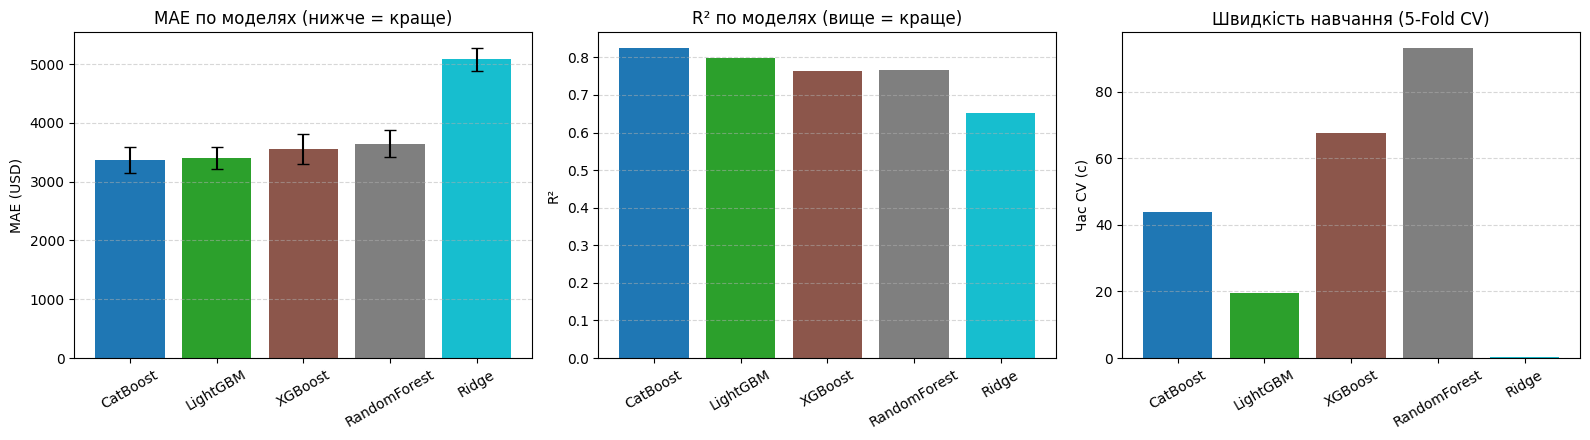

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
order = summary_df.index.tolist()
colors = plt.cm.tab10(np.linspace(0, 1, len(order)))

axes[0].bar(order, summary_df['MAE'], yerr=summary_df['MAE_std'], color=colors, capsize=4)
axes[0].set_ylabel('MAE (USD)')
axes[0].set_title('MAE по моделях (нижче = краще)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].bar(order, summary_df['R2'], color=colors)
axes[1].set_ylabel('R²')
axes[1].set_title('R² по моделях (вище = краще)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

axes[2].bar(order, summary_df['time_s'], color=colors)
axes[2].set_ylabel('Час CV (с)')
axes[2].set_title('Швидкість навчання (5-Fold CV)')
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Висновки

In [11]:
best_mae_model = summary_df['MAE'].idxmin()
best_r2_model = summary_df['R2'].idxmax()
fastest_model = summary_df['time_s'].idxmin()

print(f"Найкращий MAE : {best_mae_model} ({summary_df.loc[best_mae_model, 'MAE']:,.0f} USD)")
print(f"Найкращий R²  : {best_r2_model} ({summary_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Найшвидший     : {fastest_model} ({summary_df.loc[fastest_model, 'time_s']:.1f}с)")
print()
print(summary_df.to_string())

Найкращий MAE : CatBoost (3,367 USD)
Найкращий R²  : CatBoost (0.8255)
Найшвидший     : Ridge (0.3с)

                      MAE     MAE_std       MAPE        R2     time_s
CatBoost      3367.005611  218.541838  23.417734  0.825491  43.885543
LightGBM      3395.623979  187.570847  23.748692  0.799008  19.433963
XGBoost       3551.442239  258.509544  23.921958  0.762569  67.578329
RandomForest  3649.155292  221.477705  23.538536  0.765571  93.199436
Ridge         5080.337946  196.360650  33.264610  0.651791   0.267011


**Підсумок за результатами вище** (див. фактичні числа в таблиці й виводах команд):

- CatBoost і LightGBM залишаються найсильнішими моделями за MAE — очікувано, адже обидва мають
  нативну підтримку категоріальних ознак з високою кардинальністю (`Mark`, `Model`) без ручного
  кодування.
- CatBoost стабільно дає найкращий (найвищий) R², тобто краще пояснює дисперсію цін у верхньому і
  нижньому цінових сегментах, а не лише в середньому діапазоні.
- XGBoost і RandomForest відстають — RandomForest через простіше (частотне/target) кодування
  високо-кардинальних `Mark`/`Model` замість нативної обробки, XGBoost — через складнішу взаємодію
  `enable_categorical` з дуже рідкісними категоріями.
- Ridge — найшвидший, але і найслабший за MAE/R²: лінійна модель не вловлює нелінійні ефекти
  (наприклад, непропорційне падіння ціни при одночасно великому віці й пробігу — саме це й
  покликана вловити ознака `Age_x_Mileage`).

**Рішення:** у `main.ipynb` лишаємо **CatBoost** — виграш над LightGBM у R² та відсутність потреби
в ручному кодуванні категорій (менше місць для витоку даних/помилок у продакшн-коді `main.py`)
переважують невелику різницю в MAE.